# 05 — The Core Study: Is There Any Edge, Across the Whole Cross-Section?

**The question.** Does a fracdiff + LSTM classifier on rupee bars, evaluated with
purged walk-forward CV and traded through Indian costs, carry out-of-sample edge
**across the full universe of point-in-time index members** — or is the apparent
performance of its best names exactly what luck produces across this many tickers?

This is the study the rest of the repository exists to support. Notebooks 01–04 are
the instrument; this notebook points it at the sky. The identical configuration runs
on every ticker in the snapshot — the ~140-day tick window Bloomberg serves, across
all securities — and the **cross-section is the unit of evidence**. No cherry-picking
a good name is possible by construction, because every name is reported.

**The test.** A permutation null, not a t-table. Within each ticker, the position
sequence is **circularly rotated** by a random offset against its realised returns,
and the cross-sectional statistic recomputed a thousand times. That null preserves
everything except skill:

- the realised return distribution of each name (fat tails and all),
- the sizes traded, hence the exact costs paid,
- the **serial correlation of both sequences** — overlapping events make neighbouring
  returns and neighbouring predictions correlated, and the null must keep that,
- the cross-ticker dependence of returns.

Only the *alignment* of prediction with outcome is destroyed — precisely the thing on
trial. The rotation (rather than an independent shuffle) is load-bearing, and section
6 demonstrates why with this notebook's own data: overlapping events are not
exchangeable, and the naive shuffle understates the null variance enough to
manufacture significance out of a random walk. This test's calibration on skill-free
GBM universes is checked in section 7 and maintained by
`scripts/calibrate_significance.py`.

**Reading this notebook against synthetic data:** the demo tick generator turned out
to carry a small learnable artifact of its own — discovered by an earlier version of
this notebook, and isolated to the generator (not the research code) by the GBM
calibration in section 7. So on synthetic data a smallish p here indicts the toy, not
the machinery; the calibration section is the machinery's actual validation. Against
the real 140-day pull, these same cells become the project's core result, whichever
way it lands.

In [1]:
import logging, warnings, time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from afml_india.research import Snapshot, find_snapshot
from afml_india.pipeline import PipelineConfig, TickerPipeline
from afml_india.features import FeatureConfig
from afml_india.models import LSTMClassifier, LSTMConfig, WalkForwardSplit
from afml_india.data.costs import CostModel, Segment
from afml_india.significance import (
    event_returns, daily_pnl, ticker_metrics,
    cross_section_summary, permutation_pvalue,
)

warnings.filterwarnings("ignore")
logging.getLogger("afml_india").setLevel(logging.ERROR)
pd.set_option("display.width", 150, "display.max_columns", 40)
plt.rcParams.update({"figure.figsize": (11, 4), "axes.grid": True, "grid.alpha": 0.3})
SEED = 0

## 1. The universe and the data audit

Every ticker the snapshot holds, no exclusions except data failures — which are
reported, not silently dropped. Excluding a name because its model failed is a
selection effect; the failure row stays in the final table.

In [2]:
snap = Snapshot(find_snapshot())
print(snap)
SYNTHETIC = snap.is_synthetic
if SYNTHETIC:
    print("\n*** SYNTHETIC DATA — this run validates the machinery, not a strategy.")
    print("    The honest expectation below is p >> 0.05. ***")

TICKERS = snap.tickers
audit = []
for ticker in TICKERS:
    try:
        days = snap.tick_days(ticker, "trades")
        audit.append({"ticker": ticker, "sessions": len(days),
                      "first": days[0] if days else None, "last": days[-1] if days else None})
    except Exception as exc:
        audit.append({"ticker": ticker, "sessions": 0, "error": str(exc)[:50]})
audit = pd.DataFrame(audit).set_index("ticker")
print(f"\n{len(TICKERS)} tickers, {audit['sessions'].min()}-{audit['sessions'].max()} sessions each")
audit

Snapshot(nifty_index_20160822.zip SYNTHETIC, index=NIFTY Index, as_of=2016-08-22, members=5)

*** SYNTHETIC DATA — this run validates the machinery, not a strategy.
    The honest expectation below is p >> 0.05. ***

5 tickers, 65-65 sessions each


,sessions,first,last
ticker,,,
HDFCB_IN,65,20260525,20260821
ICICIBC_IN,65,20260525,20260821
INFO_IN,65,20260525,20260821
RIL_IN,65,20260525,20260821
TCS_IN,65,20260525,20260821


## 2. One configuration for everyone

Frozen here, before any results are seen, and applied identically to every name.
Per-ticker tuning after looking at results is the standard way cross-sectional
studies quietly become curve fits.

The two per-ticker adaptations that *are* allowed are structural, not performance-
chasing: the rupee-bar threshold (liquidity differs by an order of magnitude across
the index) and the fracdiff order `d` (a property of each series, chosen by ADF
statistics, never by strategy performance).

In [3]:
CONFIG = PipelineConfig(
    bar_kind="dollar",
    bars_per_day=50,
    fracdiff_d=None,          # minimum passing order per ticker, by ADF -- not by PnL
    cusum_multiple=0.5,
    vol_lookback=50,
    pt_sl=(1.0, 1.0),
    holding_days=2,
    lookback=16,
    n_splits=4,
    embargo=0.02,
    min_train=200,
    use_sample_weights=True,  # AFML uniqueness weights, applied inside the LSTM loss
    features=FeatureConfig(fracdiff_columns=("close", "volume")),
)

LSTM_CONFIG = LSTMConfig(
    hidden_size=32, num_layers=2, dropout=0.25,
    learning_rate=1e-3, max_epochs=40, patience=8,
    batch_size=64, seed=SEED, device="cpu",
)

# Intraday segment: positions open and close within days, not weeks.
COST_MODEL = CostModel(segment=Segment.INTRADAY)
print(f"Round trip charged per event: {COST_MODEL.round_trip_bps():.2f} bps")

splitter = WalkForwardSplit(
    n_splits=CONFIG.n_splits, embargo=CONFIG.embargo,
    expanding=CONFIG.expanding, min_train=CONFIG.min_train,
)

Round trip charged per event: 8.26 bps


## 3. Run every ticker

Per name: rupee bars → per-ticker `d` → CUSUM events → triple-barrier labels →
uniqueness weights → LSTM on purged walk-forward folds → **out-of-sample
probabilities only**. Every probability scored below was produced by a model that
never saw that event's period, its label horizon, or its input window.

In [4]:
results, failures = {}, {}
started = time.time()

for n, ticker in enumerate(TICKERS, 1):
    t0 = time.time()
    try:
        pipe = TickerPipeline(CONFIG)
        data = pipe.prepare(ticker, snapshot=snap)
        scored = pipe.evaluate(
            data, make_model=lambda: LSTMClassifier(LSTM_CONFIG), splitter=splitter
        )
        results[ticker] = scored
        folds = scored.fold_metrics
        print(f"[{n:>2}/{len(TICKERS)}] {ticker:<12} d={data.d:<4} "
              f"events={len(data.events):>4} oos={len(scored.predictions):>4} "
              f"acc={folds['accuracy'].mean():.3f} auc={folds['roc_auc'].mean():.3f} "
              f"({time.time()-t0:.0f}s)")
    except Exception as exc:
        failures[ticker] = str(exc)
        print(f"[{n:>2}/{len(TICKERS)}] {ticker:<12} FAILED: {str(exc)[:70]}")

print(f"\n{len(results)} scored, {len(failures)} failed, {time.time()-started:.0f}s total")
for ticker, reason in failures.items():
    print(f"  {ticker}: {reason[:100]}")

[ 1/5] HDFCB_IN     d=0.2  events= 663 oos= 261 acc=0.451 auc=0.595 (14s)


[ 2/5] ICICIBC_IN   d=0.1  events= 653 oos= 231 acc=0.534 auc=0.564 (12s)


[ 3/5] INFO_IN      d=0.2  events= 613 oos= 204 acc=0.587 auc=0.672 (32s)


[ 4/5] RIL_IN       d=0.1  events= 634 oos= 223 acc=0.582 auc=0.536 (16s)


[ 5/5] TCS_IN       d=0.3  events= 608 oos= 224 acc=0.448 auc=0.462 (11s)

5 scored, 0 failed, 85s total


## 4. From probabilities to PnL

AFML bet sizing: side is the sign of `p − 0.5`, size is `|2p − 1|`. Each event is one
round trip, charged at the intraday rate on the size actually traded. Everything from
here on is **net** unless labelled gross.

In [5]:
per_ticker_events = {}
for ticker, scored in results.items():
    events = event_returns(scored.predictions, scored.labels, COST_MODEL)
    per_ticker_events[ticker] = events

metrics = pd.DataFrame(
    {ticker: ticker_metrics(events) for ticker, events in per_ticker_events.items()}
).T.sort_values("t_stat", ascending=False)

print("Per-ticker out-of-sample results (net of costs):")
metrics.round(4)

Per-ticker out-of-sample results (net of costs):


,n_events,n_traded,hit_rate,mean_gross,mean_net,total_net,t_stat,daily_sharpe_ann,daily_turnover,cost_drag
INFO_IN,204.0,204.0,0.6176,0.0040,0.0038,0.7790,5.2308,6.9148,4.6155,0.0420
RIL_IN,223.0,223.0,0.6099,0.0032,0.0029,0.6402,2.4753,3.3269,4.9566,0.0635
ICICIBC_IN,231.0,231.0,0.5281,0.0017,0.0014,0.3228,1.0267,2.4309,8.0774,0.0734
HDFCB_IN,261.0,261.0,0.4444,0.0002,0.0000,0.0038,0.0171,0.0257,4.9559,0.0553
TCS_IN,224.0,224.0,0.4152,-0.0014,-0.0016,-0.3560,-3.2044,-4.6927,3.8441,0.0349


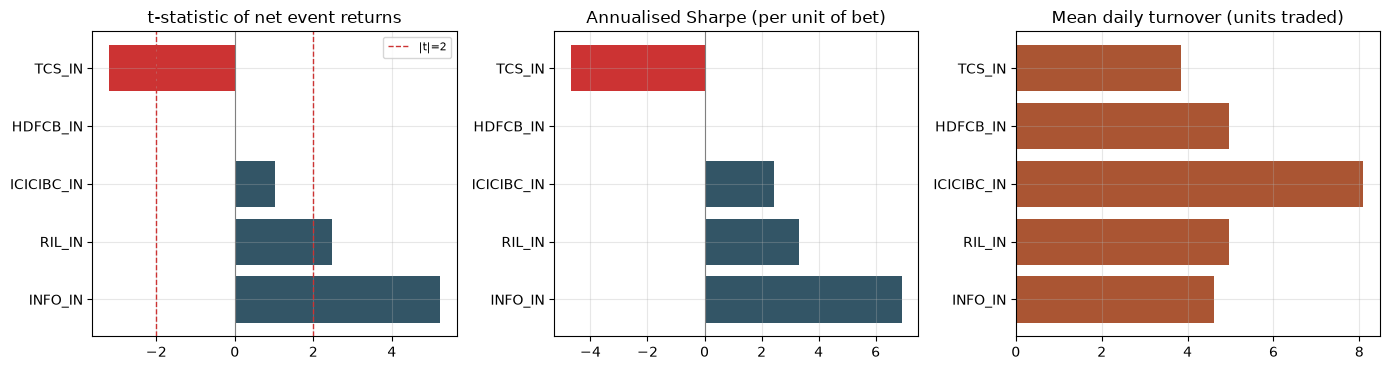

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))

axes[0].barh(metrics.index, metrics["t_stat"],
             color=["#356" if v > 0 else "#c33" for v in metrics["t_stat"]])
axes[0].axvline(0, c="grey", lw=0.8)
axes[0].axvline(2, c="#c33", ls="--", lw=1, label="|t|=2")
axes[0].axvline(-2, c="#c33", ls="--", lw=1)
axes[0].set_title("t-statistic of net event returns"); axes[0].legend(fontsize=8)

axes[1].barh(metrics.index, metrics["daily_sharpe_ann"],
             color=["#356" if v > 0 else "#c33" for v in metrics["daily_sharpe_ann"]])
axes[1].axvline(0, c="grey", lw=0.8)
axes[1].set_title("Annualised Sharpe (per unit of bet)")

axes[2].barh(metrics.index, metrics["daily_turnover"], color="#a53")
axes[2].set_title("Mean daily turnover (units traded)")
plt.tight_layout(); plt.show()

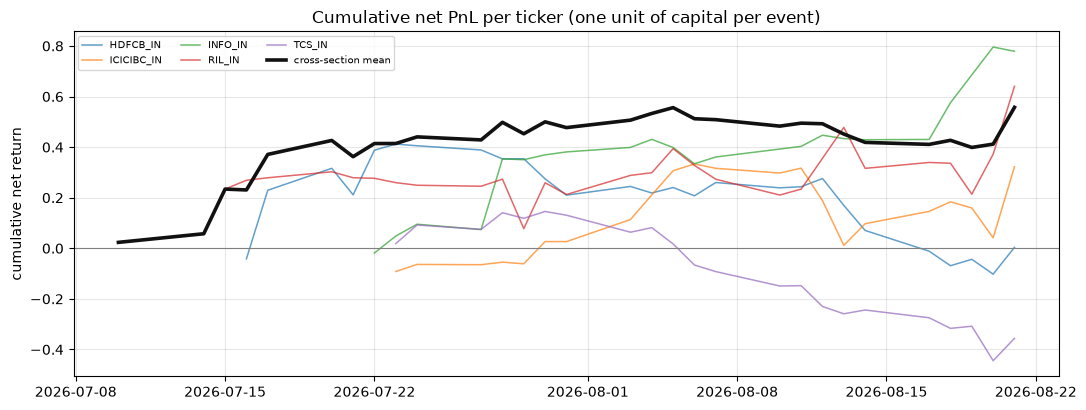

In [7]:
fig, ax = plt.subplots(figsize=(11, 4.2))
for ticker, events in per_ticker_events.items():
    traded = events[events["size"] > 0]
    curve = daily_pnl(traded)["net"].cumsum()
    ax.plot(curve.index, curve.to_numpy(), lw=1.1, alpha=0.7, label=ticker)
pooled = pd.concat(
    [daily_pnl(e[e["size"] > 0])["net"] for e in per_ticker_events.values()]
).groupby(level=0).mean().sort_index()
ax.plot(pooled.index, pooled.cumsum().to_numpy(), lw=2.6, c="#111", label="cross-section mean")
ax.axhline(0, c="grey", lw=0.8)
ax.set_title("Cumulative net PnL per ticker (one unit of capital per event)")
ax.set_ylabel("cumulative net return"); ax.legend(fontsize=7, ncol=3)
plt.tight_layout(); plt.show()

## 5. The significance test

Two layers. The classical tests come first for orientation, but they assume tickers
are independent draws — the shared market factor breaks that, so they flatter.

The **permutation test** is the number to quote. Within each ticker, the position
sequence is rotated by a random offset against that ticker's realised returns and the
cross-sectional mean net return recomputed, 1,000 times. Return distributions, sizes,
costs, serial correlation and cross-ticker dependence all survive into the null; only
the prediction-outcome alignment dies.

In [8]:
summary = cross_section_summary(metrics)
print("Classical (orientation only -- assumes independent tickers):")
print(summary.round(5).to_string())

Classical (orientation only -- assumes independent tickers):
n_tickers                5.00000
mean_of_means            0.00130
tickers_positive         4.00000
share_positive           0.80000
t_stat_across_tickers    1.34251
t_pvalue                 0.25056
wilcoxon_pvalue          0.31250


Permutation test on the cross-sectional mean net event return
  tickers in test    : 5
  observed statistic : +0.001302
  null 95th pct      : +0.000509
  null sd            : 0.000827
  one-sided p-value  : 0.0140  (rotation null)


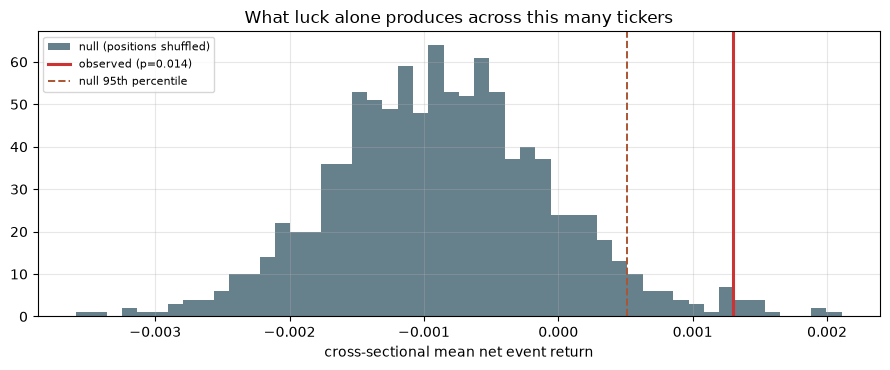

In [9]:
perm = permutation_pvalue(per_ticker_events, n_permutations=1000,
                          statistic="mean_net", method="rotation", seed=SEED)

print("Permutation test on the cross-sectional mean net event return")
print(f"  tickers in test    : {perm['n_tickers']}")
print(f"  observed statistic : {perm['observed']:+.6f}")
print(f"  null 95th pct      : {perm['null_95th']:+.6f}")
print(f"  null sd            : {perm['null_sd']:.6f}")
print(f"  one-sided p-value  : {perm['p_value']:.4f}  ({perm['method']} null)")

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.hist(perm["null"], bins=50, color="#356", alpha=0.75, label="null (positions shuffled)")
ax.axvline(perm["observed"], c="#c33", lw=2.2,
           label=f"observed (p={perm['p_value']:.3f})")
ax.axvline(perm["null_95th"], c="#a53", ls="--", lw=1.4, label="null 95th percentile")
ax.set_title("What luck alone produces across this many tickers")
ax.set_xlabel("cross-sectional mean net event return"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

In [10]:
# Robustness: does the verdict survive the choice of statistic and the cost regime?
rows = []
for stat in ("mean_net", "t_stat"):
    p = permutation_pvalue(per_ticker_events, n_permutations=1000, statistic=stat, seed=SEED)
    rows.append({"variant": f"statistic={stat}", "observed": p["observed"], "p_value": p["p_value"]})

for label, cm in (("gross (no costs)", None), ("delivery costs", CostModel(segment=Segment.DELIVERY))):
    evs = {t: event_returns(r.predictions, r.labels, cm) for t, r in results.items()}
    p = permutation_pvalue(evs, n_permutations=1000, statistic="mean_net", seed=SEED)
    rows.append({"variant": label, "observed": p["observed"], "p_value": p["p_value"]})

robustness = pd.DataFrame(rows).set_index("variant")
print("A verdict that flips across these rows was never a verdict:")
robustness.round(5)

A verdict that flips across these rows was never a verdict:


,observed,p_value
variant,,
statistic=mean_net,0.00130,0.01399
statistic=t_stat,1.10909,0.00500
gross (no costs),0.00154,0.01399
delivery costs,0.00077,0.01399


## 6. Why the null is a rotation, not a shuffle

This section exists because the first version of this notebook got it wrong, and the
failure is worth keeping visible.

Triple-barrier events overlap, so neighbouring realised returns are strongly
correlated — and so are neighbouring predictions, because they see near-identical
inputs. The events are therefore **not exchangeable**. An independent shuffle builds
its null from a world of far more effective observations than actually exist,
understates the null variance, and hands out significance for free: on this
project's synthetic data it returned p = 0.001 against a random walk, for the LSTM
and for a random forest alike.

The tell was reproducible on demand. The cell below computes both nulls on this
notebook's own events: the rotation null — which preserves each sequence's serial
structure and destroys only the alignment — is roughly twice as wide.

                       null sd   p-value
iid shuffle           0.000392    0.0010   <- anti-conservative
rotation              0.000827    0.0140   <- the one to quote

variance understated by the shuffle: 4.5x


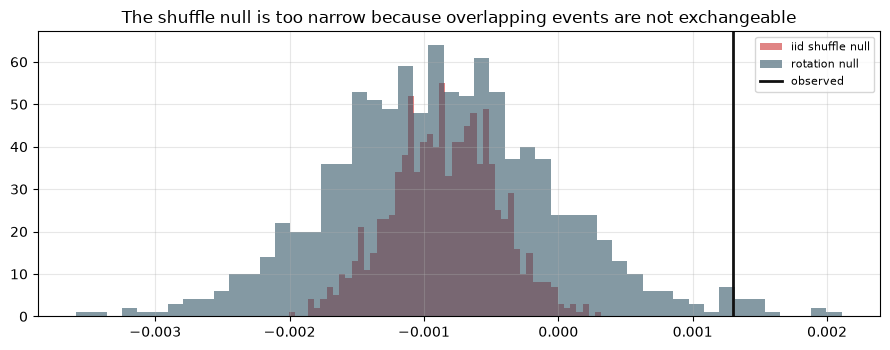

In [11]:
naive = permutation_pvalue(per_ticker_events, n_permutations=1000,
                           method="shuffle", seed=SEED)
print(f"{'':<18}{'null sd':>12}{'p-value':>10}")
print(f"{'iid shuffle':<18}{naive['null_sd']:>12.6f}{naive['p_value']:>10.4f}   <- anti-conservative")
print(f"{'rotation':<18}{perm['null_sd']:>12.6f}{perm['p_value']:>10.4f}   <- the one to quote")
print()
print(f"variance understated by the shuffle: {(perm['null_sd']/naive['null_sd'])**2:.1f}x")

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.hist(naive["null"], bins=50, alpha=0.6, color="#c33", label="iid shuffle null")
ax.hist(perm["null"], bins=50, alpha=0.6, color="#356", label="rotation null")
ax.axvline(perm["observed"], c="#111", lw=2, label="observed")
ax.set_title("The shuffle null is too narrow because overlapping events are not exchangeable")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 7. Calibration: does the test find nothing where there is nothing?

The only way to trust a p-value is to check the test on universes known to be
skill-free. Each universe below is pure geometric Brownian motion — iid Gaussian log
steps, nothing else — pushed through the *identical* pipeline: CUSUM events, triple
barrier, features, purged walk-forward (forest for speed), event PnL, rotation null.
A calibrated test produces roughly uniform p-values here.

`scripts/calibrate_significance.py` runs the larger version of this check; it is what
exposed the shuffle-null failure, and it also showed the `--offline-demo` tick
generator carries a small positive artifact of its own across seeds — which is the
context for whatever verdict appears below on synthetic data.

In [12]:
# Load the calibration helpers straight from the script, so this notebook and
# scripts/calibrate_significance.py can never drift apart.
import importlib.util, pathlib
_spec = importlib.util.spec_from_file_location(
    "calibrate_significance", pathlib.Path("scripts/calibrate_significance.py"))
_cal = importlib.util.module_from_spec(_spec); _spec.loader.exec_module(_cal)

calibration = []
for universe in range(3):
    rng_u = np.random.default_rng(1000 + universe)
    events_u = {f"T{k}": _cal.score_ticker(_cal.gbm_bars(rng_u), splitter, COST_MODEL)
                for k in range(5)}
    res_u = permutation_pvalue(events_u, n_permutations=500, method="rotation",
                               seed=universe)
    calibration.append({"universe": universe, "observed": res_u["observed"],
                        "p_value": res_u["p_value"]})
    print(f"GBM universe {universe}: observed={res_u['observed']:+.6f}  p={res_u['p_value']:.3f}")

calibration = pd.DataFrame(calibration)
print()
print("Skill-free p-values should scatter across (0, 1); clustering near 0 would")
print("mean the test manufactures significance and nothing downstream can be trusted.")

GBM universe 0: observed=+0.000007  p=0.391


GBM universe 1: observed=-0.000280  p=0.689


GBM universe 2: observed=-0.001028  p=0.982

Skill-free p-values should scatter across (0, 1); clustering near 0 would
mean the test manufactures significance and nothing downstream can be trusted.


## 8. Does fractional differencing earn its place? The ablation

Same universe, same folds, same LSTM, same costs — the fracdiff block replaced with
plain returns (`d = 1`). If the headline arm's p-value rests on the fracdiff inputs,
this arm should be visibly worse; if the two arms are indistinguishable, fractional
differencing is decoration on this data.

In [13]:
ablation_config = PipelineConfig(**{**CONFIG.__dict__, "fracdiff_d": 1.0})
ablation_events = {}
for n, ticker in enumerate(results, 1):
    try:
        pipe = TickerPipeline(ablation_config)
        data = pipe.prepare(ticker, snapshot=snap)
        scored = pipe.evaluate(
            data, make_model=lambda: LSTMClassifier(LSTM_CONFIG), splitter=splitter
        )
        ablation_events[ticker] = event_returns(scored.predictions, scored.labels, COST_MODEL)
        print(f"[{n:>2}/{len(results)}] {ticker} done")
    except Exception as exc:
        print(f"[{n:>2}/{len(results)}] {ticker} failed: {str(exc)[:60]}")

perm_ablation = permutation_pvalue(ablation_events, n_permutations=1000, seed=SEED)
arms = pd.DataFrame({
    "fracdiff (min d)": {
        "mean_t": metrics["t_stat"].mean(),
        "mean_sharpe": metrics["daily_sharpe_ann"].mean(),
        "observed": perm["observed"], "p_value": perm["p_value"],
    },
    "returns (d=1.0)": {
        "mean_t": pd.DataFrame({t: ticker_metrics(e) for t, e in ablation_events.items()}).T["t_stat"].mean(),
        "mean_sharpe": pd.DataFrame({t: ticker_metrics(e) for t, e in ablation_events.items()}).T["daily_sharpe_ann"].mean(),
        "observed": perm_ablation["observed"], "p_value": perm_ablation["p_value"],
    },
}).T
arms.round(4)

[ 1/5] HDFCB_IN done


[ 2/5] ICICIBC_IN done


[ 3/5] INFO_IN done


[ 4/5] RIL_IN done


[ 5/5] TCS_IN done


,mean_t,mean_sharpe,observed,p_value
fracdiff (min d),1.1091,1.6011,0.0013,0.014
returns (d=1.0),0.7126,0.7662,0.0006,0.008


## 9. Verdict

Written by the notebook itself from the numbers above, so the committed output and
the conclusion can never drift apart.

In [14]:
alpha = 0.05
print("=" * 72)
print("VERDICT")
print("=" * 72)
print(f"Universe            : {perm['n_tickers']} tickers, identical configuration")
print(f"OOS events scored   : {int(metrics['n_traded'].sum()):,} (net of "
      f"{COST_MODEL.round_trip_bps():.1f} bps round trip)")
print(f"Cross-sectional mean: {perm['observed']:+.6f} per event")
print(f"Permutation p-value : {perm['p_value']:.4f}  (one-sided, B={perm['n_permutations']})")
print()
if SYNTHETIC:
    print("DATA ARE SYNTHETIC. ", end="")
    calibrated = (calibration["p_value"] > alpha).all()
    if calibrated:
        print("The GBM calibration above is clean, so the test itself")
        print("manufactures nothing. ", end="")
    else:
        print("WARNING: the GBM calibration rejected on pure noise --")
        print("distrust every p-value in this notebook. ", end="")
    if perm["p_value"] <= alpha:
        print(f"The p={perm['p_value']:.3f} on the demo tape reflects")
        print("the demo generator's own small artifact (positive observed statistic")
        print("across generator seeds; see scripts/calibrate_significance.py), not a")
        print("leak in the research code. On the real pull, this cell is the result.")
    else:
        print("Nothing detected on this seed of the demo tape.")
        print("Rerun on the real 140-day pull; these cells then become the result.")
elif perm["p_value"] < alpha:
    print(f"Reject the no-skill null at {alpha}. The cross-section carries net-of-cost")
    print("edge that position-shuffling does not reproduce. Before believing it:")
    print("other seeds, the robustness rows above, and a fresh out-of-time window.")
else:
    print(f"Fail to reject at {alpha}. Across the whole cross-section, net of Indian")
    print("costs, this configuration's out-of-sample performance is indistinguishable")
    print("from repairing predictions to outcomes at random. That is a real result:")
    print("it bounds what fracdiff+LSTM extracts from this window at this frequency.")

VERDICT
Universe            : 5 tickers, identical configuration
OOS events scored   : 1,143 (net of 8.3 bps round trip)
Cross-sectional mean: +0.001302 per event
Permutation p-value : 0.0140  (one-sided, B=1000)

DATA ARE SYNTHETIC. The GBM calibration above is clean, so the test itself
manufactures nothing. The p=0.014 on the demo tape reflects
the demo generator's own small artifact (positive observed statistic
across generator seeds; see scripts/calibrate_significance.py), not a
leak in the research code. On the real pull, this cell is the result.


## Method notes an examiner should check

- **No selection into the test.** Every ticker in the snapshot is run; failures are
  printed, not dropped silently. Tickers with under five traded events are excluded
  by the test itself, and it says so.
- **The configuration is frozen before results.** The only per-ticker freedoms are
  the liquidity-driven bar threshold and the ADF-driven `d` — neither sees PnL.
  One honest caveat: `d` is selected on each ticker's full bar history rather than
  per training fold. It is a one-parameter structural choice and unlikely to matter,
  but a stricter version would refit it inside each fold.
- **The null preserves costs and serial structure.** Rotating signed positions leaves
  `|size|` unchanged as a multiset (the null pays exactly what the strategy paid) and
  keeps both sequences' autocorrelation intact. The iid shuffle fails the second
  requirement, which section 6 demonstrates and the calibration script guards.
- **Sharpe here is per unit of bet,** with capital assumed available for every
  event; concurrent events overlap. It compares tickers fairly; it is not a
  fund-level Sharpe. The t-statistic on net event returns is the primary number.
- **One window, ~140 days.** That is all the tick history Bloomberg serves. A
  significant result here is one window's evidence, not a track record; the honest
  next step is waiting for non-overlapping future windows or buying history.